![banner](../../../docs/figs/brand_identity/banner.png)

# Week 5: Multilayer Perceptrons

## Lesson overview

Train a small multilayer perceptron on California housing data to predict median house values. The inputs are area features; the outputs are price predictions and training plots.

**By the end, you can:** identify the input features and prediction target; explain why the data is scaled first; and inspect training loss and test predictions.

**Before you begin:** The notebook reads the California housing CSV included under `data/`; no dataset download is needed. Predictions are model estimates, not actual sale prices. Plots appear in the notebook.

<p align="center"><img src="../figs/ml_housing_learning_map.svg" alt="Eight housing features enter a 64-unit ReLU layer and produce one predicted price; schematic training and validation curves sit beside the network" width="100%"><br><em>Figure 1. Read the model's input, hidden layer, and output before interpreting its loss curves.</em></p>

**Use the figure:** Find the eight feature columns and the single predicted target in the code. After training, compare the actual training and validation curves with the schematic curves; a lower training loss alone does not establish good performance on new rows.


## Why this example matters

A neural network is useful here because it can combine several housing features through learned layers. The lesson connects the model diagram to training loss and held-out prediction errors.

**Inputs and requirements:** The included California housing CSV, PyTorch, pandas, and matplotlib are used. A loss is the quantity minimized during training; validation checks examples that do not update the weights.

**Route through the lesson:** Inspect inputs and targets → scale and batch training data → define the MLP → compare training and validation loss → inspect test predictions.

**As you work:** Before each model or plot cell, predict one result. After it runs, describe one observation, identify its source, and name one limitation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
from ccai9012 import nn_utils, viz_utils

## Step 1: Load the housing price dataset from the repository

Load the housing examples and inspect the feature names. Each row represents an area, and each column provides information the model can use.

In [ ]:
from ccai9012.paths import DATA_DIR

california = pd.read_csv(DATA_DIR / "housing_price_california.csv", index_col=0)
feature_names = list(california.drop(columns="Target").columns)
X_california = california[feature_names].to_numpy()
y_california = california["Target"].to_numpy()
print("Local California housing data loaded:", len(california), "rows")
print("Feature names:", feature_names)


In [ ]:
# Feature explanations for California Housing dataset:
# MedInc    : Median income in the area (in tens of thousands of dollars)
# HouseAge  : Average age of the houses in the area (in years)
# AveRooms  : Average number of rooms per household
# AveBedrms : Average number of bedrooms per household
# Population: Total population in the area
# AveOccup  : Average number of occupants per household
# Latitude  : Geographic latitude of the area
# Longitude : Geographic longitude of the area

# Target variable explanation:
# Target    : Median house value for households within the area (in units of 100,000 dollars)

# showcase the dataset
df = pd.DataFrame(X_california, columns=feature_names)
df['Target'] = y_california
df.head()

## Step 2: Prepare input data for model training

Separate the input features from the price target, then scale the inputs and group them into batches. Scaling helps values with different units work together during training.

In [5]:
# Normarlize data and prepare dataloaders
train_loader, val_loader, test_loader, scaler = nn_utils.prepare_dataloaders(
    X_california,
    y_california,
    batch_size=64,
    train_ratio=0.8,
    val_ratio=0.1
)

## Step 3: Model Build: Two-layer MLP

The model takes a batch of features and returns a price estimate. Read the architecture diagram by following the arrows from input to output.

### Read the MLP diagram

The eight input numbers pass through a hidden layer, which combines and transforms them, and then reach one output unit for a price estimate. The diagram below is a **structure map**, not a display of learned feature importance. **Pause and predict:** What shape should a batch of 64 input rows have, and how many predictions should the model return?


In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # regression output
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

input_dim = X_california.shape[1]  # 8 features
hidden_dim = 64         # can tune this

model = SimpleMLP(input_dim, hidden_dim)

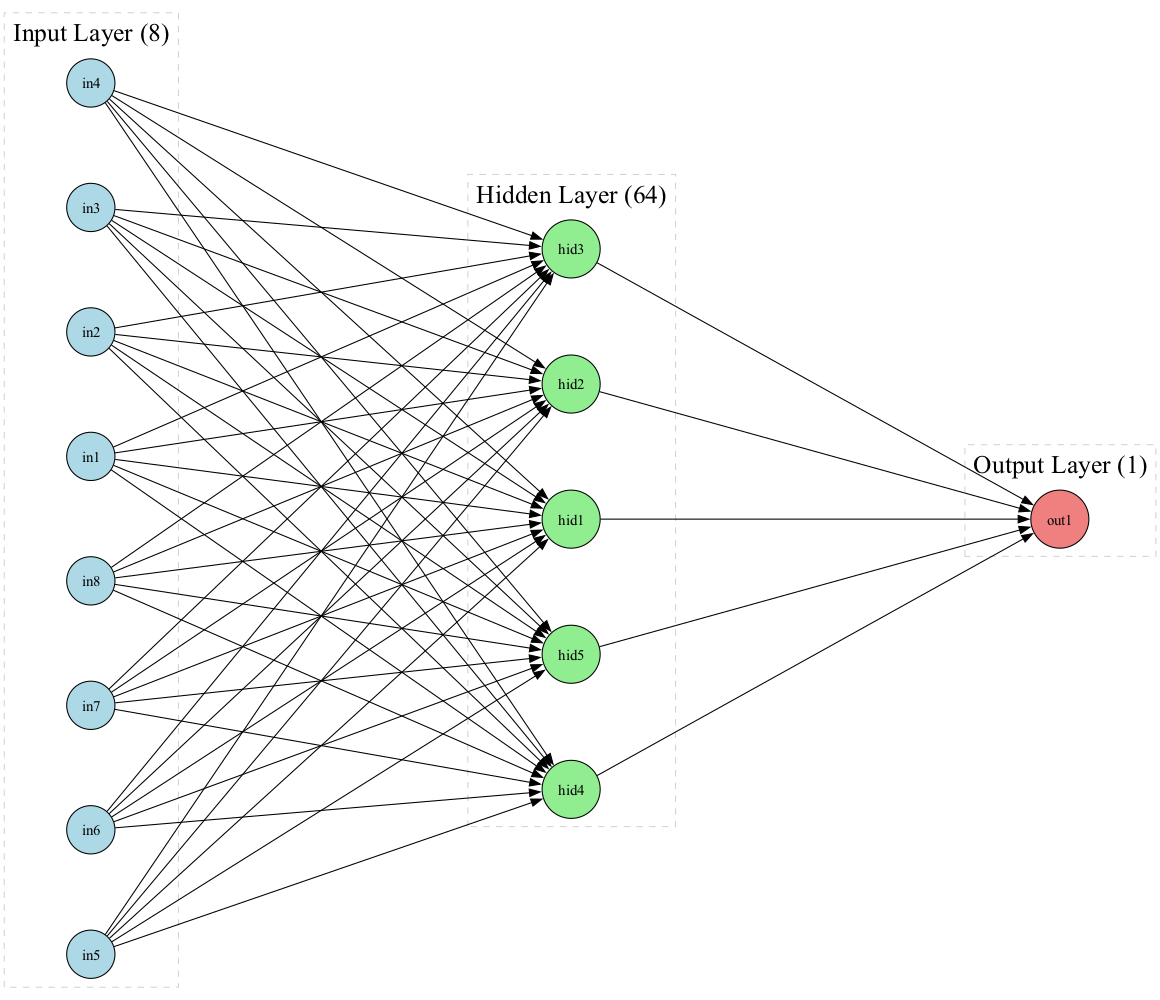

In [7]:
# Visualizing the model architecture
viz_utils.draw_simple_mlp(input_size=8,hidden_size=64,output_size=1,hidden_display=5)

## Step 4: Model Training

Fit the model. Training loss measures errors on training examples; validation loss shows how it performs on examples that do not update the model.

**Read the loss plot:** Compare training and validation curves over epochs. If training loss keeps falling while validation loss rises, what might that suggest about generalization? The curves summarize this split, not all California neighbourhoods.


In [8]:
# Training Setup
learning_rate = 0.001  # step size for optimizer
num_epochs = 50        # number of passes over entire dataset
criterion = nn.MSELoss()  # Mean Squared Error loss for regression
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
train_losses, val_losses = nn_utils.train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    criterion, 
    num_epochs
)

Epoch [1/50] - Train Loss: 1.9844, Val Loss: 0.7259
Epoch [2/50] - Train Loss: 0.6527, Val Loss: 0.5381
Epoch [3/50] - Train Loss: 0.4964, Val Loss: 0.4572
Epoch [4/50] - Train Loss: 0.4346, Val Loss: 0.4214
Epoch [5/50] - Train Loss: 0.4102, Val Loss: 0.4068
Epoch [6/50] - Train Loss: 0.3967, Val Loss: 0.4009
Epoch [7/50] - Train Loss: 0.3881, Val Loss: 0.3913
Epoch [8/50] - Train Loss: 0.3812, Val Loss: 0.3877
Epoch [9/50] - Train Loss: 0.3756, Val Loss: 0.3829
Epoch [10/50] - Train Loss: 0.3692, Val Loss: 0.3826
Epoch [11/50] - Train Loss: 0.3644, Val Loss: 0.3775
Epoch [12/50] - Train Loss: 0.3595, Val Loss: 0.3694
Epoch [13/50] - Train Loss: 0.3549, Val Loss: 0.3638
Epoch [14/50] - Train Loss: 0.3497, Val Loss: 0.3622
Epoch [15/50] - Train Loss: 0.3480, Val Loss: 0.3559
Epoch [16/50] - Train Loss: 0.3432, Val Loss: 0.3570
Epoch [17/50] - Train Loss: 0.3525, Val Loss: 0.3543
Epoch [18/50] - Train Loss: 0.3394, Val Loss: 0.3508
Epoch [19/50] - Train Loss: 0.3376, Val Loss: 0.3507
Ep

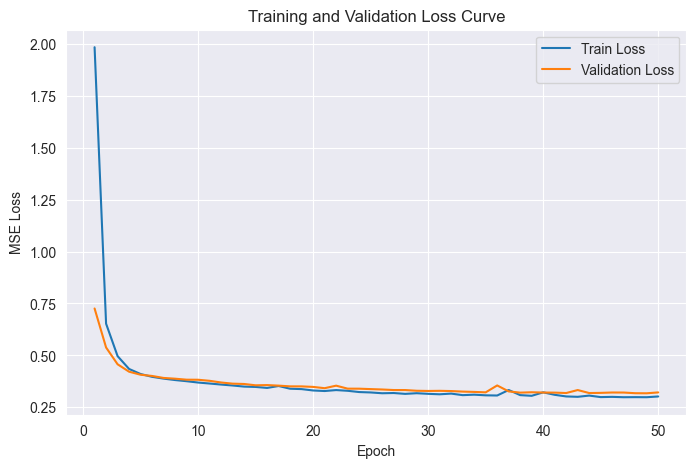

In [10]:
# Plot Training and Validation Loss
viz_utils.plot_loss_curve(train_losses, val_losses)

## Step 5: Test Model Performance

Compare predicted prices with the recorded targets in the held-out data. The error is measured in price units, and accuracy may vary across areas.

**Interpretation prompt:** Find one large residual and state whether the model over- or under-predicts. The held-out test set estimates error for this dataset; the values are census-block medians, not individual sale prices.


MSE: 0.2966
RMSE: 0.5446
MAE: 0.3791
MAPE: 21.46%
R^2 Score: 0.7773


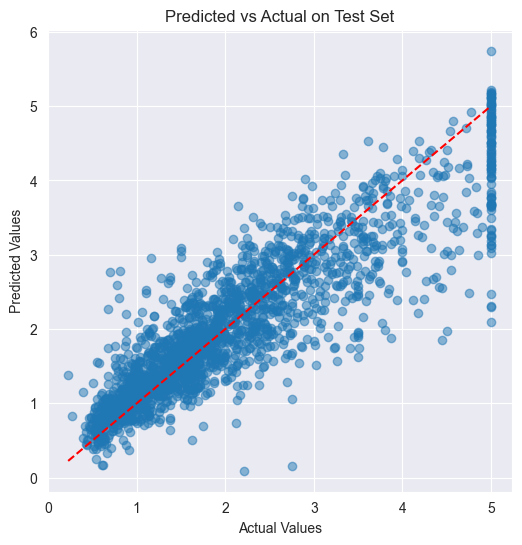

In [11]:
results = nn_utils.evaluate_regression_model(
    model,
    test_loader,
    show_examples=True,
    metrics=['rmse', 'mse', 'mae', 'mape']
)

## What to take away

The MLP estimates house values from area features. **Try next:** Change the network size and compare validation results. **Limit:** The training data and predictions are not a substitute for a current market valuation.